# Breakline-Derived Reference Lines And USGS Gauge Points

This notebook authors 2D HEC-RAS reference features from hydraulic geometry,
not arbitrary straight lines. It uses channel-aligned 2D breaklines as
longitudinal reference lines, generates 250 ft perpendicular transects from
those centerlines, adds USGS gauge reference points inside the model domain,
then runs geometry preprocessing and full plan execution through
`ras_commander`.


In [1]:
# pip install --upgrade ras-commander


**For Development**: run this notebook from the repository root with the local
source tree on `PYTHONPATH`.


In [2]:
from pathlib import Path
import logging
import math
import re
import shutil
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from scipy.spatial import cKDTree
from rasterio.windows import from_bounds
from shapely.geometry import LineString, MultiLineString, Point, box
from shapely.ops import unary_union

from IPython.display import display

from ras_commander import (
    GeomReferenceFeatures,
    HdfBndry,
    HdfMesh,
    HdfResultsMesh,
    HdfResultsPlan,
    HdfResultsQuery,
    HdfResultsXsec,
    RasCmdr,
    RasCurrency,
    RasExamples,
    RasMap,
    init_ras_project,
    ras,
)
from ras_commander.usgs import UsgsGaugeSpatial

warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger("ras_commander").setLevel(logging.WARNING)
logging.getLogger("dataretrieval").setLevel(logging.WARNING)

pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 140)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Parameters

Geometry `09` is used because it contains the named channel breaklines
`Upper`, `Middle`, and `Lower`. Plan `03` is the matching single-2D plan for
that geometry.


In [3]:
PROJECT_NAME = "BaldEagleCrkMulti2D"
PROJECT_VERSION = "7.0"
TARGET_PLAN_NUMBER = "03"
TARGET_GEOMETRY_NUMBER = "09"
STORAGE_AREA_NAME = "BaldEagleCr"

CHANNEL_BREAKLINE_NAMES = ["Upper", "Middle", "Lower"]
TRANSVERSE_WIDTH_FT = 250.0
CENTERLINE_SAMPLE_SPACING_FT = 7_500.0
INCLUDE_CENTERLINE_ENDS = True
PROFILE_SAMPLE_COUNT = 40

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
OUTPUT_ROOT = REPO_ROOT / "working" / "314_reference_line_generation"
PROJECT_OUTPUT = OUTPUT_ROOT / "example_projects"
FIGURE_DIR = OUTPUT_ROOT / "figures"
LINE_FIGURE_DIR = FIGURE_DIR / "reference_lines"
POINT_FIGURE_DIR = FIGURE_DIR / "reference_points"

if OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)
for folder in [PROJECT_OUTPUT, FIGURE_DIR, LINE_FIGURE_DIR, POINT_FIGURE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Output folder: {OUTPUT_ROOT}")


Output folder: <workspace>\working\314_reference_line_generation


## Extract And Inspect The Example Project

The project is extracted to `working/` so the source example data stays
unchanged. The notebook uses the project DataFrames to resolve plan, geometry,
and terrain paths instead of ad hoc file discovery.


In [4]:
project_path = RasExamples.extract_project(
    PROJECT_NAME,
    output_path=PROJECT_OUTPUT,
    suffix="314_reference_lines",
)
init_ras_project(project_path, PROJECT_VERSION)

plan_row = ras.plan_df[
    ras.plan_df["plan_number"].astype(str).str.zfill(2).eq(TARGET_PLAN_NUMBER)
].iloc[0]
geom_row = ras.geom_df[
    ras.geom_df["geom_number"].astype(str).str.zfill(2).eq(TARGET_GEOMETRY_NUMBER)
].iloc[0]

geom_file = Path(geom_row["full_path"])
geom_hdf = Path(geom_row["hdf_path"])
storage_area = STORAGE_AREA_NAME
plan_hdf = Path(project_path) / f"{ras.project_name}.p{TARGET_PLAN_NUMBER}.hdf"

if str(plan_row["geometry_number"]).zfill(2) != TARGET_GEOMETRY_NUMBER:
    raise RuntimeError(
        f"Plan {TARGET_PLAN_NUMBER} uses geometry {plan_row['geometry_number']}, "
        f"not target geometry {TARGET_GEOMETRY_NUMBER}."
    )

terrain_layers = RasMap.list_terrain_layers(project_path)
terrain_hdf = Path(terrain_layers.iloc[0]["resolved_path"])
dem_candidates = (
    sorted(terrain_hdf.parent.glob("*.dtm_20ft.tif"))
    or sorted(terrain_hdf.parent.glob("*.tif"))
)
if not dem_candidates:
    raise FileNotFoundError(f"No terrain raster found near {terrain_hdf}")
dem_path = dem_candidates[0]

mesh_areas = HdfMesh.get_mesh_areas(geom_hdf)
mesh_cells = HdfMesh.get_mesh_cell_polygons(geom_hdf)
bc_lines = HdfBndry.get_bc_lines(geom_hdf)
all_breaklines = HdfBndry.get_breaklines(geom_hdf)

if mesh_areas.empty or all_breaklines.empty:
    raise RuntimeError("Target geometry did not expose mesh areas and breaklines.")

project_summary = pd.DataFrame(
    [
        {"item": "project", "value": ras.project_name},
        {"item": "plan", "value": f"{TARGET_PLAN_NUMBER} - {plan_row['Plan Title']}"},
        {"item": "geometry", "value": f"{TARGET_GEOMETRY_NUMBER} - {geom_row['geom_title']}"},
        {"item": "2D mesh area", "value": storage_area},
        {"item": "mesh cells", "value": len(mesh_cells)},
        {"item": "breaklines", "value": len(all_breaklines)},
        {"item": "boundary condition lines", "value": len(bc_lines)},
        {"item": "terrain raster", "value": dem_path.name},
    ]
)
display(project_summary)


,item,value
0,project,BaldEagleDamBrk
1,plan,03 - Single 2D Area - Internal Dam Structure
2,geometry,09 - Single 2D Area - Internal Dam Structure
3,2D mesh area,BaldEagleCr
4,mesh cells,18066
5,breaklines,4
6,boundary condition lines,3
7,terrain raster,Terrain50.dtm_20ft.tif


## Model Context Before Authoring

An engineer reviewing this reference-feature workflow needs to see the 2D mesh,
the hydraulic breaklines used as channel centerlines, boundary-condition
locations, the active terrain surface, nearby structures, and USGS stations
inside the model domain. The overview map below is used to verify that the
generated features are tied to the modeled channel corridor and not to an
arbitrary straight guide line.


## Select Channel Breaklines And USGS Gauge Points

The `Upper`, `Middle`, and `Lower` breaklines trace the Bald Eagle Creek
channel corridor. They are used directly as longitudinal reference lines and as
the source centerlines for transverse reference-line generation.


In [5]:
def _mesh_union(mesh_gdf):
    if hasattr(mesh_gdf.geometry, "union_all"):
        return mesh_gdf.geometry.union_all()
    return unary_union(mesh_gdf.geometry)


def _safe_name(value):
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(value).strip()).strip("_")


centerline_breaklines = all_breaklines[
    all_breaklines["Name"].isin(CHANNEL_BREAKLINE_NAMES)
].copy()
missing_breaklines = sorted(set(CHANNEL_BREAKLINE_NAMES) - set(centerline_breaklines["Name"]))
if missing_breaklines:
    raise RuntimeError(f"Missing target channel breaklines: {missing_breaklines}")

centerline_breaklines["length_ft"] = centerline_breaklines.geometry.length
centerline_breaklines = centerline_breaklines.set_index("Name").loc[
    CHANNEL_BREAKLINE_NAMES
].reset_index()

raw_gauges = UsgsGaugeSpatial.find_gauges_in_project(
    geom_hdf,
    buffer_percent=0.0,
    parameter_codes=None,
    active_only=False,
    include_1d=False,
    include_2d=True,
    include_storage=False,
)
if raw_gauges.empty or "geometry" not in raw_gauges:
    raise RuntimeError("USGS query returned no gauge geometries for the model extent.")

mesh_domain = _mesh_union(mesh_areas)
gauges_projected = raw_gauges.to_crs(mesh_areas.crs)
domain_gauges = gauges_projected[
    gauges_projected.geometry.within(mesh_domain)
    | gauges_projected.geometry.touches(mesh_domain)
].copy()
if domain_gauges.empty:
    raise RuntimeError("USGS query returned no gauges inside the 2D mesh domain.")

domain_gauges["site_no"] = domain_gauges["site_no"].astype(str)
domain_gauges["ref_name"] = "USGS_" + domain_gauges["site_no"]
domain_gauges = domain_gauges.sort_values(["site_no"]).reset_index(drop=True)

centerline_table = centerline_breaklines[["Name", "length_ft"]].copy()
centerline_table["length_ft"] = centerline_table["length_ft"].round(1)
display(centerline_table)

gauge_columns = [
    column
    for column in ["site_no", "station_nm", "site_type_code", "site_status", "ref_name"]
    if column in domain_gauges.columns
]
display(domain_gauges[gauge_columns])


,Name,length_ft
0,Upper,8700.8
1,Middle,10299.8
2,Lower,15780.0


,site_no,station_nm,site_type_code,ref_name
0,01545800,"WB Susquehanna River at Lock Haven, PA",ST,USGS_01545800
1,01547280,"Antis Run near Milesburg, PA",ST,USGS_01547280
2,01547400,"Bald Eagle Creek near Milesburg, PA",ST,USGS_01547400
3,01547450,"Bald Eagle Creek at Howard, PA",ST,USGS_01547450
4,01547500,"Bald Eagle Creek at Blanchard, PA",ST,USGS_01547500
5,01547700,"Marsh Creek at Blanchard, PA",ST,USGS_01547700
6,01547980,"Beech Creek at Beech Creek, PA",ST,USGS_01547980
7,01547990,"Beech Creek near Beech Creek, PA",ST,USGS_01547990
8,01548000,"Bald Eagle Creek at Beech Creek Station, PA",ST,USGS_01548000
9,01548005,"Bald Eagle Creek near Beech Creek Station, PA",ST,USGS_01548005


## Model Overview Map

The hillshade is the active HEC-RAS terrain. Mesh cells, boundary-condition
lines, all 2D breaklines, selected channel centerlines, and in-domain USGS
gauges are overlaid for context.


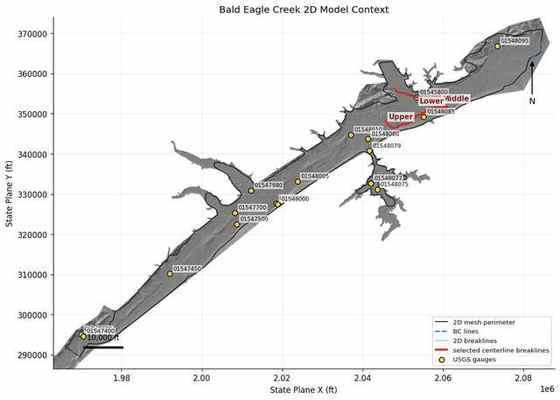

Saved overview map: <workspace>\working\314_reference_line_generation\figures\314_model_overview.png


In [6]:
def hillshade(elevation, x_resolution, y_resolution, azimuth=315, altitude=45):
    data = np.asarray(elevation.filled(np.nan), dtype=float)
    dx, dy = np.gradient(data, x_resolution, y_resolution)
    slope = np.pi / 2.0 - np.arctan(np.hypot(dx, dy))
    aspect = np.arctan2(-dx, dy)
    azimuth_rad = np.deg2rad(360.0 - azimuth + 90.0)
    altitude_rad = np.deg2rad(altitude)
    shaded = (
        np.sin(altitude_rad) * np.sin(slope)
        + np.cos(altitude_rad) * np.cos(slope) * np.cos(azimuth_rad - aspect)
    )
    return np.clip(shaded, 0.0, 1.0)


def padded_bounds(bounds, pad):
    return (bounds[0] - pad, bounds[1] - pad, bounds[2] + pad, bounds[3] + pad)


def terrain_window(raster_path, bounds):
    with rasterio.open(raster_path) as src:
        window = from_bounds(*bounds, transform=src.transform)
        data = src.read(1, window=window, masked=True, boundless=True)
        left, bottom, right, top = rasterio.windows.bounds(window, src.transform)
        extent = (left, right, bottom, top)
        shade = hillshade(data, abs(src.res[0]), abs(src.res[1]))
    return shade, extent


def add_north_arrow(ax):
    ax.annotate(
        "N",
        xy=(0.955, 0.88),
        xytext=(0.955, 0.76),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=11,
        arrowprops={"arrowstyle": "-|>", "lw": 1.3, "color": "black"},
    )


def add_scale_bar(ax, length_ft=10_000):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    x0 = xmin + 0.06 * (xmax - xmin)
    y0 = ymin + 0.06 * (ymax - ymin)
    ax.plot([x0, x0 + length_ft], [y0, y0], color="black", lw=3, solid_capstyle="butt")
    ax.text(
        x0 + length_ft / 2,
        y0 + 0.018 * (ymax - ymin),
        f"{length_ft:,.0f} ft",
        ha="center",
        va="bottom",
        fontsize=9,
    )


def save_current_figure(path):
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, bbox_inches="tight")
    return path


overview_bounds = padded_bounds(mesh_areas.total_bounds, 3_000)
shade, extent = terrain_window(dem_path, overview_bounds)

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(shade, extent=extent, cmap="Greys", alpha=0.78, origin="upper")
if not mesh_cells.empty:
    mesh_cells.boundary.plot(ax=ax, linewidth=0.08, color="#7a7a7a", alpha=0.30)
mesh_areas.boundary.plot(ax=ax, linewidth=1.2, color="#202020", label="2D mesh perimeter")
if not bc_lines.empty:
    bc_lines.plot(ax=ax, linewidth=1.6, color="#2a6fbb", linestyle="--", label="BC lines")
all_breaklines.plot(ax=ax, linewidth=1.0, color="#8d6e63", alpha=0.55, label="2D breaklines")
centerline_breaklines.plot(ax=ax, linewidth=2.5, color="#d62728", label="selected centerline breaklines")
domain_gauges.plot(ax=ax, color="#ffd43b", edgecolor="black", markersize=42, label="USGS gauges")

centerline_label_offsets = {
    "Upper": (-1_800, 2_200),
    "Middle": (2_300, 1_800),
    "Lower": (2_400, -2_000),
}
centerline_label_stations = {"Upper": 0.42, "Middle": 0.58, "Lower": 0.72}
for _, row in centerline_breaklines.iterrows():
    label = row["Name"]
    point = row.geometry.interpolate(centerline_label_stations.get(label, 0.55), normalized=True)
    dx, dy = centerline_label_offsets.get(label, (1_800, 1_800))
    ax.annotate(
        label,
        xy=(point.x, point.y),
        xytext=(point.x + dx, point.y + dy),
        fontsize=9,
        weight="bold",
        color="#7f1d1d",
        arrowprops={"arrowstyle": "-", "lw": 0.8, "color": "#7f1d1d", "alpha": 0.8},
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78, "pad": 1.6},
    )

for _, row in domain_gauges.iterrows():
    ax.text(
        row.geometry.x + 850,
        row.geometry.y + 850,
        row["site_no"],
        fontsize=7,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.65, "pad": 1.0},
    )

ax.set_xlim(overview_bounds[0], overview_bounds[2])
ax.set_ylim(overview_bounds[1], overview_bounds[3])
ax.set_title("Bald Eagle Creek 2D Model Context")
ax.set_xlabel("State Plane X (ft)")
ax.set_ylabel("State Plane Y (ft)")
ax.set_aspect("equal")
add_north_arrow(ax)
add_scale_bar(ax, length_ft=10_000)
ax.legend(loc="lower right", frameon=True, fontsize=8)
overview_path = save_current_figure(FIGURE_DIR / "314_model_overview.png")
plt.show()

print(f"Saved overview map: {overview_path}")


## Generate Breakline-Derived Reference Lines

Each selected breakline is inserted as a longitudinal reference line. Transverse
reference lines are then generated perpendicular to the local centerline tangent
at each sampling point. The transverse width is 250 ft, centered on the
breakline, and each line is clipped to the terrain footprint before writing.


In [7]:
def _longest_line(geometry):
    if isinstance(geometry, LineString):
        return geometry
    if isinstance(geometry, MultiLineString):
        return max(list(geometry.geoms), key=lambda part: part.length)
    raise TypeError(f"Expected line geometry, got {geometry.geom_type}")


def _clip_line_to_polygon(line, polygon):
    clipped = line.intersection(polygon)
    if clipped.is_empty:
        return None
    if isinstance(clipped, LineString):
        return clipped if clipped.length > 0 else None
    if isinstance(clipped, MultiLineString):
        valid_parts = [part for part in clipped.geoms if part.length > 0]
        return max(valid_parts, key=lambda part: part.length) if valid_parts else None
    line_parts = [part for part in getattr(clipped, "geoms", []) if isinstance(part, LineString)]
    return max(line_parts, key=lambda part: part.length) if line_parts else None


def _trim_reference_records(records, polygon, *, clip_label):
    trimmed = []
    dropped = []
    for record in records:
        line = _longest_line(LineString(record["coordinates"]))
        clipped = _clip_line_to_polygon(line, polygon)
        if clipped is None or clipped.length < 1.0:
            dropped.append({"name": record.get("name"), "source_name": record.get("source_name")})
            continue
        out = dict(record)
        out["coordinates"] = list(clipped.coords)
        out[f"trimmed_length_{clip_label}_ft"] = float(clipped.length)
        out[f"was_trimmed_to_{clip_label}"] = not math.isclose(
            clipped.length,
            line.length,
            rel_tol=0.0,
            abs_tol=0.01,
        )
        trimmed.append(out)
    return trimmed, dropped


def _reference_line_compatibility_report(records, mesh_polygon, tolerance_ft=0.01):
    check_polygon = mesh_polygon.buffer(tolerance_ft)
    rows = []
    for record in records:
        line = _longest_line(LineString(record["coordinates"]))
        outside_mesh = line.difference(check_polygon)
        rows.append(
            {
                "name": record["name"],
                "role": record["role"],
                "source_name": record.get("source_name"),
                "length_ft": float(line.length),
                "outside_mesh_length_ft": float(outside_mesh.length),
                "covered_by_mesh": bool(check_polygon.covers(line)),
                "start_in_mesh": bool(check_polygon.covers(line.interpolate(0.0))),
                "end_in_mesh": bool(check_polygon.covers(line.interpolate(line.length))),
            }
        )
    return pd.DataFrame(rows)


with rasterio.open(dem_path) as src:
    terrain_footprint = box(*src.bounds)

mesh_domain = _mesh_union(mesh_areas[mesh_areas["mesh_name"].eq(storage_area)])
reference_clip_polygon = mesh_domain.intersection(terrain_footprint)
if reference_clip_polygon.is_empty:
    raise RuntimeError("The target 2D mesh does not overlap the terrain footprint.")

longitudinal_reference_lines = []
for _, row in centerline_breaklines.iterrows():
    line = _longest_line(row.geometry)
    clipped = _clip_line_to_polygon(line, reference_clip_polygon)
    if clipped is None:
        raise RuntimeError(f"Centerline breakline {row['Name']} is outside the 2D mesh/terrain domain.")
    longitudinal_reference_lines.append(
        {
            "name": f"BE_CL_{_safe_name(row['Name'])}",
            "coordinates": list(clipped.coords),
            "storage_area": storage_area,
            "source_name": row["Name"],
            "role": "longitudinal_breakline",
            "station": np.nan,
            "line_length": float(clipped.length),
            "orientation": "breakline",
            "orientation_angle": np.nan,
            "tangent_angle": np.nan,
            "center": tuple(clipped.interpolate(0.5, normalized=True).coords[0]),
            "trimmed_length_mesh_ft": float(clipped.length),
            "was_trimmed_to_mesh": not math.isclose(
                clipped.length,
                line.length,
                rel_tol=0.0,
                abs_tol=0.01,
            ),
        }
    )

transverse_candidates = GeomReferenceFeatures.generate_reference_lines_from_longitudinal_line(
    centerline_breaklines[["Name", "geometry"]],
    spacing=CENTERLINE_SAMPLE_SPACING_FT,
    line_length=TRANSVERSE_WIDTH_FT,
    include_end=INCLUDE_CENTERLINE_ENDS,
    name_template="BE_XS_{source_name}_{index:02d}_{station_int}",
    storage_area=storage_area,
)
for record in transverse_candidates:
    record["role"] = "transverse_perpendicular"

transverse_reference_lines, dropped_transverse_lines = _trim_reference_records(
    transverse_candidates,
    reference_clip_polygon,
    clip_label="mesh",
)
all_reference_lines = longitudinal_reference_lines + transverse_reference_lines

if not transverse_reference_lines:
    raise RuntimeError("No transverse reference lines were generated inside the 2D mesh domain.")

compatibility_report = _reference_line_compatibility_report(all_reference_lines, mesh_domain)
incompatible_lines = compatibility_report[
    (compatibility_report["length_ft"] < 1.0)
    | (compatibility_report["outside_mesh_length_ft"] > 0.01)
    | ~compatibility_report["covered_by_mesh"]
    | ~compatibility_report["start_in_mesh"]
    | ~compatibility_report["end_in_mesh"]
]
if not incompatible_lines.empty:
    display(incompatible_lines)
    raise RuntimeError("Reference-line geometry is not fully compatible with the target 2D mesh domain.")

reference_line_rows = []
for record in all_reference_lines:
    line = LineString(record["coordinates"])
    reference_line_rows.append(
        {
            "name": record["name"],
            "role": record["role"],
            "source_name": record["source_name"],
            "station_ft": record.get("station"),
            "length_ft": line.length,
            "orientation": record.get("orientation"),
            "orientation_angle": record.get("orientation_angle"),
            "trimmed_to_mesh": record.get("was_trimmed_to_mesh", False),
        }
    )

reference_line_table = pd.DataFrame(reference_line_rows)
display(
    reference_line_table.assign(
        station_ft=lambda frame: frame["station_ft"].round(1),
        length_ft=lambda frame: frame["length_ft"].round(1),
        orientation_angle=lambda frame: frame["orientation_angle"].round(1),
    )
)
display(
    compatibility_report.assign(
        length_ft=lambda frame: frame["length_ft"].round(1),
        outside_mesh_length_ft=lambda frame: frame["outside_mesh_length_ft"].round(3),
    )
)
if dropped_transverse_lines:
    display(pd.DataFrame(dropped_transverse_lines))


,name,role,source_name,station_ft,length_ft,orientation,orientation_angle,trimmed_to_mesh
0,BE_CL_Upper,longitudinal_breakline,Upper,NaN,8700.8,breakline,NaN,False
1,BE_CL_Middle,longitudinal_breakline,Middle,NaN,10299.8,breakline,NaN,False
2,BE_CL_Lower,longitudinal_breakline,Lower,NaN,15780.0,breakline,NaN,False
3,BE_XS_Upper_01_0,transverse_perpendicular,Upper,0.0,250.0,normal,56.4,False
4,BE_XS_Upper_02_7500,transverse_perpendicular,Upper,7500.0,250.0,normal,116.4,False
5,BE_XS_Upper_03_8701,transverse_perpendicular,Upper,8700.8,250.0,normal,115.2,False
6,BE_XS_Middle_01_0,transverse_perpendicular,Middle,0.0,250.0,normal,126.5,False
7,BE_XS_Middle_02_7500,transverse_perpendicular,Middle,7500.0,250.0,normal,104.2,False
8,BE_XS_Middle_03_10300,transverse_perpendicular,Middle,10299.8,250.0,normal,98.1,False
9,BE_XS_Lower_01_0,transverse_perpendicular,Lower,0.0,250.0,normal,203.8,False


,name,role,source_name,length_ft,outside_mesh_length_ft,covered_by_mesh,start_in_mesh,end_in_mesh
0,BE_CL_Upper,longitudinal_breakline,Upper,8700.8,0.0,True,True,True
1,BE_CL_Middle,longitudinal_breakline,Middle,10299.8,0.0,True,True,True
2,BE_CL_Lower,longitudinal_breakline,Lower,15780.0,0.0,True,True,True
3,BE_XS_Upper_01_0,transverse_perpendicular,Upper,250.0,0.0,True,True,True
4,BE_XS_Upper_02_7500,transverse_perpendicular,Upper,250.0,0.0,True,True,True
5,BE_XS_Upper_03_8701,transverse_perpendicular,Upper,250.0,0.0,True,True,True
6,BE_XS_Middle_01_0,transverse_perpendicular,Middle,250.0,0.0,True,True,True
7,BE_XS_Middle_02_7500,transverse_perpendicular,Middle,250.0,0.0,True,True,True
8,BE_XS_Middle_03_10300,transverse_perpendicular,Middle,250.0,0.0,True,True,True
9,BE_XS_Lower_01_0,transverse_perpendicular,Lower,250.0,0.0,True,True,True


## Map Authored Reference Features

This zooms to the selected centerline corridor so the perpendicular 250 ft
transects can be inspected against the terrain and source breaklines.


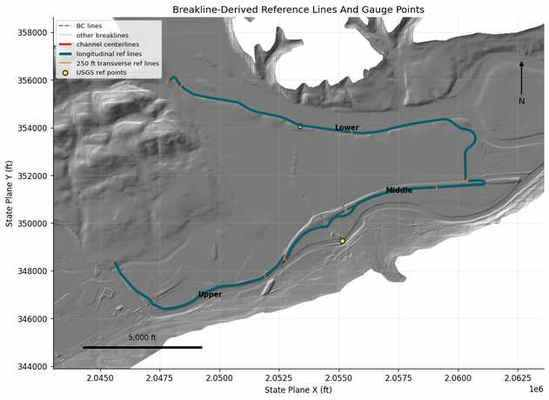

Saved authored-feature map: <workspace>\working\314_reference_line_generation\figures\314_authored_reference_features.png


In [8]:
reference_line_gdf = gpd.GeoDataFrame(
    reference_line_table,
    geometry=[LineString(item["coordinates"]) for item in all_reference_lines],
    crs=mesh_areas.crs,
)
reference_point_records = [
    {
        "name": row["ref_name"],
        "site_no": row["site_no"],
        "station_nm": row.get("station_nm", ""),
        "x": float(row.geometry.x),
        "y": float(row.geometry.y),
        "geometry": row.geometry,
    }
    for _, row in domain_gauges.iterrows()
]
reference_point_gdf = gpd.GeoDataFrame(reference_point_records, geometry="geometry", crs=mesh_areas.crs)

feature_bounds = padded_bounds(reference_line_gdf.total_bounds, 2_500)
shade, extent = terrain_window(dem_path, feature_bounds)

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(shade, extent=extent, cmap="Greys", alpha=0.82, origin="upper")
mesh_cells.cx[feature_bounds[0]:feature_bounds[2], feature_bounds[1]:feature_bounds[3]].boundary.plot(
    ax=ax,
    linewidth=0.12,
    color="#7a7a7a",
    alpha=0.35,
)
if not bc_lines.empty:
    bc_lines.plot(ax=ax, linewidth=1.4, color="#2a6fbb", linestyle="--", label="BC lines")
all_breaklines.plot(ax=ax, linewidth=1.0, color="#8d6e63", alpha=0.45, label="other breaklines")
centerline_breaklines.plot(ax=ax, linewidth=2.6, color="#d62728", label="channel centerlines")
reference_line_gdf[reference_line_gdf["role"].eq("longitudinal_breakline")].plot(
    ax=ax,
    linewidth=3.2,
    color="#005f73",
    label="longitudinal ref lines",
)
reference_line_gdf[reference_line_gdf["role"].eq("transverse_perpendicular")].plot(
    ax=ax,
    linewidth=1.2,
    color="#f97316",
    label="250 ft transverse ref lines",
)
reference_point_gdf.plot(ax=ax, color="#ffd43b", edgecolor="black", markersize=38, label="USGS ref points")

for _, row in centerline_breaklines.iterrows():
    point = row.geometry.interpolate(0.52, normalized=True)
    ax.text(point.x, point.y, row["Name"], fontsize=9, weight="bold")

ax.set_xlim(feature_bounds[0], feature_bounds[2])
ax.set_ylim(feature_bounds[1], feature_bounds[3])
ax.set_title("Breakline-Derived Reference Lines And Gauge Points")
ax.set_xlabel("State Plane X (ft)")
ax.set_ylabel("State Plane Y (ft)")
ax.set_aspect("equal")
add_north_arrow(ax)
add_scale_bar(ax, length_ft=5_000)
ax.legend(loc="upper left", fontsize=8)
features_path = save_current_figure(FIGURE_DIR / "314_authored_reference_features.png")
plt.show()

print(f"Saved authored-feature map: {features_path}")


## Write Reference Lines And Points To Geometry

The plain-text geometry is the authored source. Reference points are written as
HEC-RAS IC points with the `Reference Point` prefix, then parsed back from the
same `.g09` file before any preprocessing is attempted.


In [9]:
inserted_line_count = GeomReferenceFeatures.add_reference_lines(
    geom_file,
    all_reference_lines,
    storage_area=storage_area,
)
inserted_point_count = GeomReferenceFeatures.add_reference_points(
    geom_file,
    [{"name": row["name"], "x": row["x"], "y": row["y"]} for row in reference_point_records],
)

parsed_lines = GeomReferenceFeatures.get_reference_lines(geom_file)
parsed_points = GeomReferenceFeatures.get_reference_points(geom_file)

expected_line_names = {item["name"] for item in all_reference_lines}
expected_point_names = {f"Reference Point {item['name']}" for item in reference_point_records}
parsed_line_names = {item["name"] for item in parsed_lines}
parsed_point_names = {item["name"] for item in parsed_points}

missing_lines = sorted(expected_line_names - parsed_line_names)
missing_points = sorted(expected_point_names - parsed_point_names)
if missing_lines or missing_points:
    raise RuntimeError(
        f"Plain-text round trip missing lines={missing_lines}, points={missing_points}"
    )

authoring_summary = pd.DataFrame(
    [
        {"check": "reference lines inserted", "value": inserted_line_count},
        {"check": "reference lines parsed", "value": len(expected_line_names)},
        {"check": "USGS reference points inserted", "value": inserted_point_count},
        {"check": "USGS reference points parsed", "value": len(expected_point_names)},
    ]
)
display(authoring_summary)


,check,value
0,reference lines inserted,13
1,reference lines parsed,13
2,USGS reference points inserted,17
3,USGS reference points parsed,17


## Execute The Full Plan With Geometry Preprocessing

`RasCmdr.compute_plan(clear_geompre=True, force_rerun=True)` clears the
geometry preprocessor files after the reference features are authored, then
runs HEC-RAS from the command line. This provides the required round trip:
plain-text geometry authoring, HEC-RAS geometry preprocessing, full hydraulic
compute, and HDF result generation. The checks are hard failures so reference
line / 2D mesh incompatibilities cannot pass silently.


In [10]:
compute_result = RasCmdr.compute_plan(
    TARGET_PLAN_NUMBER,
    clear_geompre=True,
    force_rerun=True,
    num_cores=2,
    verify=True,
)

compute_succeeded = bool(compute_result)
plan_hdf_exists = plan_hdf.exists()

if not compute_succeeded:
    raise RuntimeError(
        "Full HEC-RAS plan execution failed verification after reference-feature authoring. "
        "Check the captured HEC-RAS compute log for reference-line / 2D mesh diagnostics."
    )
if not plan_hdf_exists:
    raise FileNotFoundError(f"Plan HDF not created at {plan_hdf}; compute did not produce results.")

compute_messages = HdfResultsPlan.get_compute_messages(plan_hdf)
geometry_preprocess_messages_found = (
    "Geometric Preprocessor" in compute_messages
    and "Finished Processing Geometry" in compute_messages
)
if not geometry_preprocess_messages_found:
    raise RuntimeError("Computed HDF messages do not show completed geometry preprocessing.")

geometry_preprocess_summary = pd.DataFrame(
    [
        {"field": "geometry_preprocess_messages_found", "value": geometry_preprocess_messages_found},
        {"field": "compute_success", "value": bool(compute_result)},
        {"field": "plan_hdf", "value": str(plan_hdf)},
        {"field": "plan_hdf_size_mb", "value": round(plan_hdf.stat().st_size / 1024**2, 2)},
    ]
)
if compute_result.results_df_row is not None:
    for column in ["completed", "runtime_complete_process_hours", "vol_error_percent"]:
        if column in compute_result.results_df_row.index:
            geometry_preprocess_summary.loc[len(geometry_preprocess_summary)] = {
                "field": column,
                "value": compute_result.results_df_row[column],
            }
display(geometry_preprocess_summary)

compiled_lines = HdfBndry.get_reference_lines(plan_hdf, mesh_name=storage_area)
compiled_line_names = set(compiled_lines["Name"].astype(str)) if not compiled_lines.empty else set()

missing_compiled_lines = sorted(expected_line_names - compiled_line_names)
if missing_compiled_lines:
    raise RuntimeError(
        "Computed plan HDF is missing authored reference lines: "
        f"{missing_compiled_lines}"
    )

display(
    pd.DataFrame(
        [
            {"compiled feature": "reference lines", "count": len(compiled_lines)},
            {
                "compiled feature": "USGS reference points",
                "count": len(reference_point_records),
                "note": "authored as geometry IC/reference points; WSE is sampled from computed 2D mesh cells",
            },
        ]
    )
)


,field,value
0,geometry_preprocess_messages_found,True
1,compute_success,True
2,plan_hdf,\symphony-workspaces\ras-commander\CLB-70...
3,plan_hdf_size_mb,60.77
4,completed,True
5,runtime_complete_process_hours,0.044293
6,vol_error_percent,0.029283


,compiled feature,count,note
0,reference lines,13,NaN
1,USGS reference points,17,authored as geometry IC/reference points; WSE ...


## Extract Reference Feature Results

Reference-line output is read from the native HEC-RAS reference-line group in
the computed plan HDF. For USGS reference points, this HEC-RAS 7.0 example
does not emit a native `Reference Points` result group from IC-point-authored
geometry points, so the notebook resolves each authored point to its nearest
2D cell and extracts the WSE time series from the computed mesh results.


In [11]:
line_ds = HdfResultsXsec.get_ref_lines_timeseries(plan_hdf)

if not line_ds.data_vars:
    raise RuntimeError("Computed plan HDF contains no reference-line time-series output.")

line_result_names = [str(value) for value in line_ds.coords["refln_name"].values]
missing_line_results = sorted(expected_line_names - set(line_result_names))
if missing_line_results:
    raise RuntimeError(f"Reference-line results missing authored names: {missing_line_results}")

mesh_cell_points = HdfMesh.get_mesh_cell_points(geom_hdf)
mesh_cell_points = mesh_cell_points[mesh_cell_points["mesh_name"].eq(storage_area)].copy()
cell_xy = np.array([(point.x, point.y) for point in mesh_cell_points.geometry], dtype=float)
gauge_xy = np.array([[item["x"], item["y"]] for item in reference_point_records], dtype=float)
distances, nearest_indices = cKDTree(cell_xy).query(gauge_xy)
nearest_cells = mesh_cell_points.iloc[nearest_indices].reset_index(drop=True)

for index, record in enumerate(reference_point_records):
    record["cell_id"] = int(nearest_cells.loc[index, "cell_id"])
    record["cell_distance_ft"] = float(distances[index])

point_wse_da = HdfResultsMesh.get_mesh_timeseries(
    plan_hdf,
    storage_area,
    "Water Surface",
    truncate=False,
)

line_result_summary = pd.DataFrame(
    {
        "result_type": "reference line",
        "name": line_result_names,
    }
)
point_result_summary = pd.DataFrame(
    [
        {
            "result_type": "USGS reference point",
            "name": record["name"],
            "site_no": record["site_no"],
            "cell_id": record["cell_id"],
            "cell_distance_ft": round(record["cell_distance_ft"], 1),
        }
        for record in reference_point_records
    ]
)
display(pd.concat([line_result_summary, point_result_summary], ignore_index=True))
display(
    pd.DataFrame(
        [
            {"dataset": "reference lines", "variables": ", ".join(line_ds.data_vars)},
            {"dataset": "USGS reference points", "variables": "Water Surface from 2D mesh cell time series"},
        ]
    )
)


,result_type,name,site_no,cell_id,cell_distance_ft
0,reference line,BE_CL_Upper,NaN,NaN,NaN
1,reference line,BE_CL_Middle,NaN,NaN,NaN
2,reference line,BE_CL_Lower,NaN,NaN,NaN
3,reference line,BE_XS_Upper_01_0,NaN,NaN,NaN
4,reference line,BE_XS_Upper_02_7500,NaN,NaN,NaN
5,reference line,BE_XS_Upper_03_8701,NaN,NaN,NaN
6,reference line,BE_XS_Middle_01_0,NaN,NaN,NaN
7,reference line,BE_XS_Middle_02_7500,NaN,NaN,NaN
8,reference line,BE_XS_Middle_03_10300,NaN,NaN,NaN
9,reference line,BE_XS_Lower_01_0,NaN,NaN,NaN


,dataset,variables
0,reference lines,"Area, Depth Hydraulic, Depth Max, Flow, Fricti..."
1,USGS reference points,Water Surface from 2D mesh cell time series


## Plot Results For Each Reference Line

The notebook writes one figure per reference line so each authored feature has
an individual, reviewable result artifact. Each figure pairs a terrain/max-WSE
profile with the selected HEC-RAS reference-line time series.


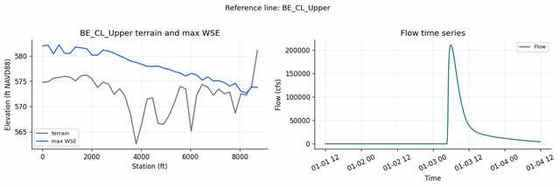

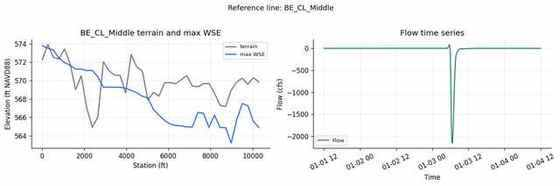

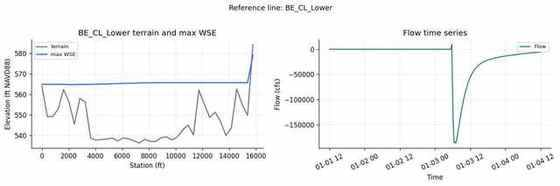

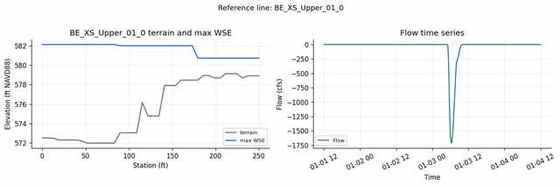

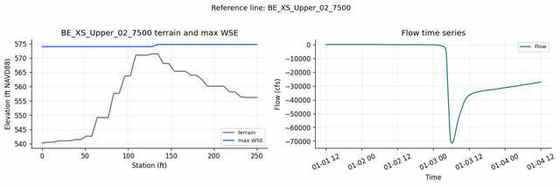

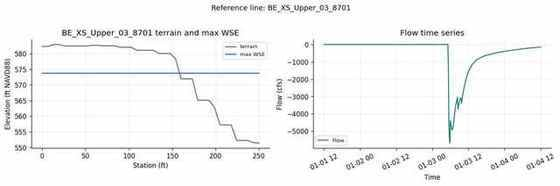

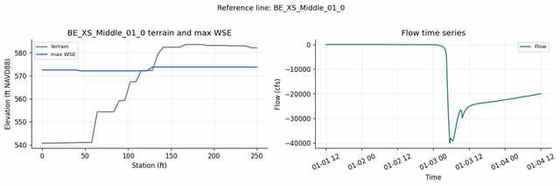

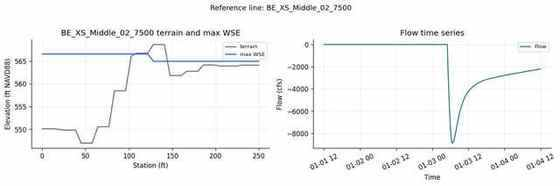

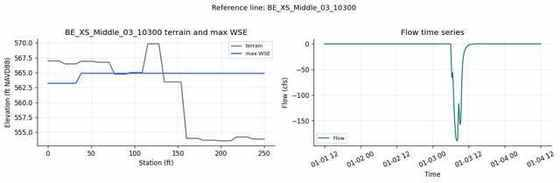

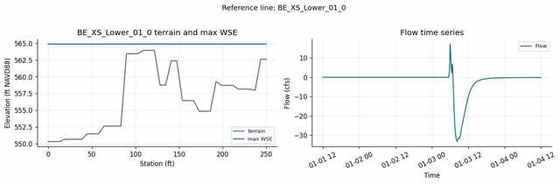

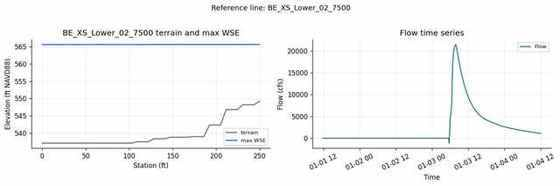

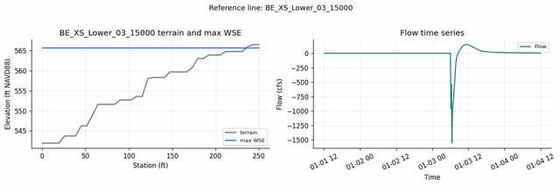

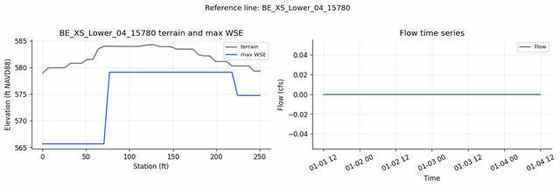

,reference_line,figure
0,BE_CL_Upper,\symphony-workspaces\ras-commander\CLB-70...
1,BE_CL_Middle,\symphony-workspaces\ras-commander\CLB-70...
2,BE_CL_Lower,\symphony-workspaces\ras-commander\CLB-70...
3,BE_XS_Upper_01_0,\symphony-workspaces\ras-commander\CLB-70...
4,BE_XS_Upper_02_7500,\symphony-workspaces\ras-commander\CLB-70...
5,BE_XS_Upper_03_8701,\symphony-workspaces\ras-commander\CLB-70...
6,BE_XS_Middle_01_0,\symphony-workspaces\ras-commander\CLB-70...
7,BE_XS_Middle_02_7500,\symphony-workspaces\ras-commander\CLB-70...
8,BE_XS_Middle_03_10300,\symphony-workspaces\ras-commander\CLB-70...
9,BE_XS_Lower_01_0,\symphony-workspaces\ras-commander\CLB-70...


In [12]:
def _first_existing_variable(dataset, candidates):
    for candidate in candidates:
        if candidate in dataset.data_vars:
            return candidate
    return next(iter(dataset.data_vars))


def _feature_index(names, target):
    return [str(value) for value in names].index(target)


def sample_terrain_profile(line, raster_path, n_samples=PROFILE_SAMPLE_COUNT):
    distances = np.linspace(0.0, line.length, n_samples)
    points = [line.interpolate(distance) for distance in distances]
    coords = [(point.x, point.y) for point in points]
    with rasterio.open(raster_path) as src:
        values = np.array([float(sample[0]) for sample in src.sample(coords)], dtype=float)
        if src.nodata is not None:
            values[np.isclose(values, src.nodata)] = np.nan
    return pd.DataFrame({"station_ft": distances, "terrain_ft": values})


def query_wse_profile(line, hdf_path, n_samples=PROFILE_SAMPLE_COUNT):
    distances = np.linspace(0.0, line.length, n_samples)
    points = [line.interpolate(distance) for distance in distances]
    coords = np.array([(point.x, point.y) for point in points], dtype=float)
    profile = HdfResultsQuery.query_points(
        hdf_path,
        coords,
        variable="wse",
        time_index="max",
        ras_object=ras,
    )
    profile.insert(0, "station_ft", distances)
    profile = profile.rename(columns={"value": "max_wse_ft"})
    return profile


def chunked(values, size):
    for start in range(0, len(values), size):
        yield values[start:start + size]


line_wse_var = _first_existing_variable(line_ds, ["Water Surface", "Depth Hydraulic", "Depth"])
line_series_var = _first_existing_variable(line_ds, ["Flow", "Water Surface", "Velocity"])
line_names = line_ds.coords["refln_name"].values
line_plot_paths = []
line_plot_records = []

line_records_by_name = {item["name"]: item for item in all_reference_lines}
ordered_line_names = [item["name"] for item in all_reference_lines]

for line_number, line_name in enumerate(ordered_line_names, start=1):
    record = line_records_by_name[line_name]
    line = LineString(record["coordinates"])
    terrain_profile = sample_terrain_profile(line, dem_path)
    wse_profile = query_wse_profile(line, plan_hdf)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), squeeze=False)
    ax_profile = axes[0, 0]
    ax_profile.plot(terrain_profile["station_ft"], terrain_profile["terrain_ft"], color="#6b7280", lw=1.6, label="terrain")
    ax_profile.plot(wse_profile["station_ft"], wse_profile["max_wse_ft"], color="#2563eb", lw=1.6, label="max WSE")
    ax_profile.set_xlabel("Station (ft)")
    ax_profile.set_ylabel("Elevation (ft NAVD88)")
    ax_profile.set_title(f"{line_name} terrain and max WSE")
    ax_profile.legend(loc="best", fontsize=8)

    idx = _feature_index(line_names, line_name)
    da = line_ds[line_series_var].isel(refln_id=idx)
    times = pd.to_datetime(da.coords["time"].values)
    ax_series = axes[0, 1]
    ax_series.plot(times, da.values, color="#0f766e", lw=1.4, label=line_series_var)
    units = da.attrs.get("units", "")
    ax_series.set_xlabel("Time")
    ax_series.set_title(f"{line_series_var} time series")
    ax_series.set_ylabel(f"{line_series_var} ({units})" if units else line_series_var)
    ax_series.tick_params(axis="x", labelrotation=25)
    ax_series.legend(loc="best", fontsize=8)

    fig.suptitle(f"Reference line: {line_name}", fontsize=11, y=1.02)
    fig.tight_layout()
    safe_name = _safe_name(line_name)
    path = LINE_FIGURE_DIR / f"314_reference_line_results_{line_number:02d}_{safe_name}.png"
    saved_path = save_current_figure(path)
    line_plot_paths.append(saved_path)
    line_plot_records.append({"reference_line": line_name, "figure": str(saved_path)})
    plt.show()

display(pd.DataFrame(line_plot_records))


## Plot Results For Each USGS Reference Point

Each figure is a USGS gauge reference point inserted into the model geometry.
The WSE time series is extracted from the nearest computed 2D mesh cell at the
authored point location.


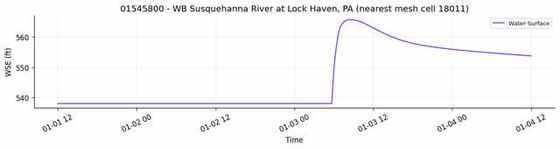

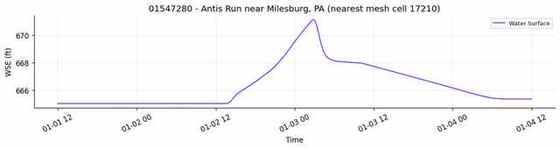

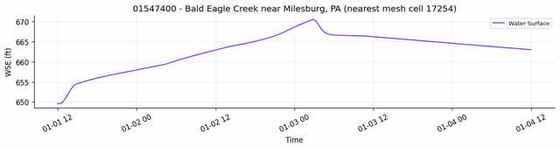

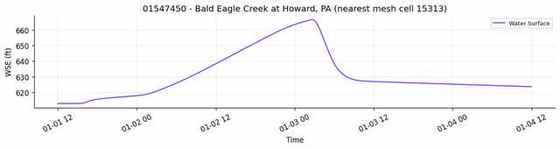

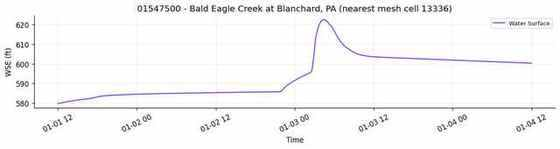

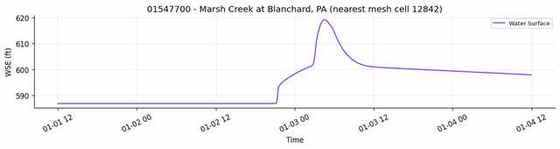

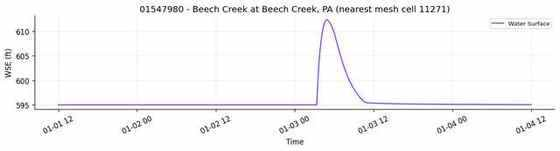

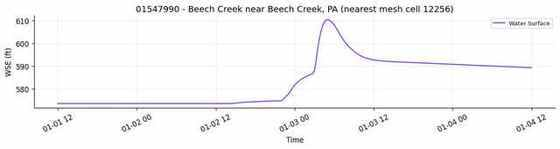

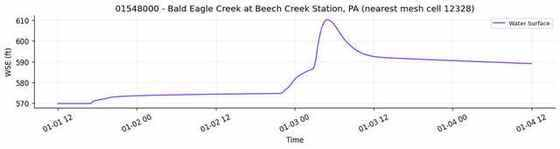

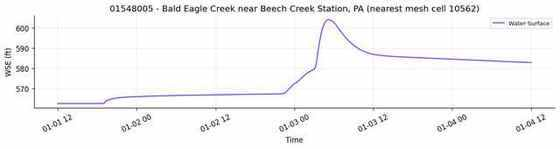

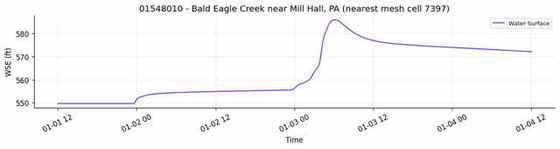

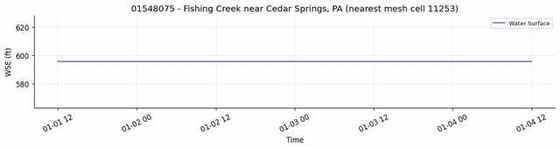

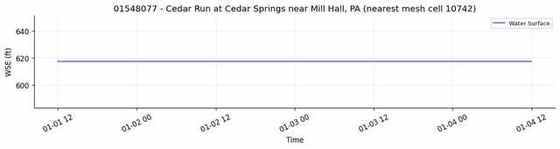

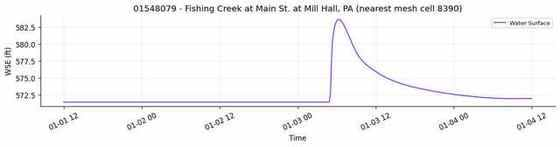

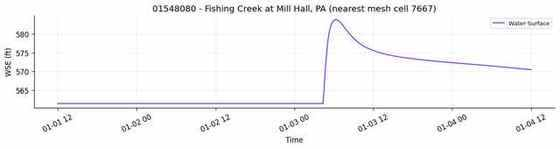

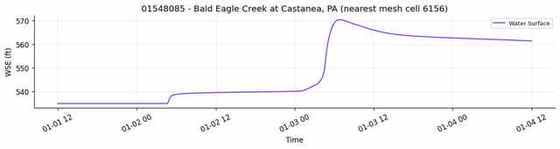

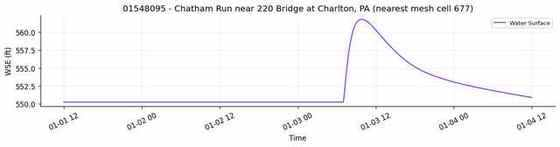

,reference_point,site_no,figure
0,USGS_01545800,01545800,\symphony-workspaces\ras-commander\CLB-70...
1,USGS_01547280,01547280,\symphony-workspaces\ras-commander\CLB-70...
2,USGS_01547400,01547400,\symphony-workspaces\ras-commander\CLB-70...
3,USGS_01547450,01547450,\symphony-workspaces\ras-commander\CLB-70...
4,USGS_01547500,01547500,\symphony-workspaces\ras-commander\CLB-70...
5,USGS_01547700,01547700,\symphony-workspaces\ras-commander\CLB-70...
6,USGS_01547980,01547980,\symphony-workspaces\ras-commander\CLB-70...
7,USGS_01547990,01547990,\symphony-workspaces\ras-commander\CLB-70...
8,USGS_01548000,01548000,\symphony-workspaces\ras-commander\CLB-70...
9,USGS_01548005,01548005,\symphony-workspaces\ras-commander\CLB-70...


In [13]:
point_plot_paths = []
point_plot_records = []
point_units = point_wse_da.attrs.get("units", "ft")

for point_number, record in enumerate(reference_point_records, start=1):
    da = point_wse_da.sel(cell_id=record["cell_id"])
    times = pd.to_datetime(da.coords["time"].values)

    fig, ax = plt.subplots(figsize=(11, 3.0))
    ax.plot(times, da.values, color="#7c3aed", lw=1.4, label="Water Surface")
    station_label = str(record.get('station_nm', '')).strip()
    title = f"{record['site_no']} - {station_label}" if station_label else record['site_no']
    ax.set_title(f"{title} (nearest mesh cell {record['cell_id']})")
    ax.set_xlabel("Time")
    ax.set_ylabel(f"WSE ({point_units})")
    ax.tick_params(axis="x", labelrotation=25)
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()

    safe_name = _safe_name(record["name"])
    path = POINT_FIGURE_DIR / f"314_reference_point_wse_{point_number:02d}_{safe_name}.png"
    saved_path = save_current_figure(path)
    point_plot_paths.append(saved_path)
    point_plot_records.append({
        "reference_point": record["name"],
        "site_no": record["site_no"],
        "figure": str(saved_path),
    })
    plt.show()

display(pd.DataFrame(point_plot_records))


## Round-Trip Result

The checks below are intentionally strict: they verify geometry authoring,
compiled HDF persistence, full plan execution, native reference-line result
extraction, and WSE extraction at each authored USGS gauge reference-point
location from the computed 2D mesh results.


In [14]:
result_summary_rows = [
    {"acceptance_check": "channel breaklines selected", "value": len(centerline_breaklines)},
    {"acceptance_check": "longitudinal reference lines from breaklines", "value": len(longitudinal_reference_lines)},
    {"acceptance_check": "250 ft transverse reference lines", "value": len(transverse_reference_lines)},
    {"acceptance_check": "USGS reference points inside domain", "value": len(reference_point_records)},
    {"acceptance_check": "geometry preprocessing messages found", "value": geometry_preprocess_messages_found},
    {"acceptance_check": "full RasCmdr plan execution succeeded", "value": compute_succeeded},
    {"acceptance_check": "reference-line result variables", "value": ", ".join(line_ds.data_vars)},
    {"acceptance_check": "reference-point WSE time series", "value": "Water Surface from 2D mesh cell time series"},
    {"acceptance_check": "reference-line figures", "value": len(line_plot_paths)},
    {"acceptance_check": "reference-point figures", "value": len(point_plot_paths)},
]

result_summary = pd.DataFrame(result_summary_rows)
display(result_summary)

if not geometry_preprocess_messages_found or not compute_succeeded:
    raise RuntimeError("Reference-feature round trip did not complete plan execution and geometry preprocessing.")
if len(line_plot_paths) != len(all_reference_lines):
    raise RuntimeError(
        f"Expected {len(all_reference_lines)} reference-line figures, got {len(line_plot_paths)}."
    )
if len(point_plot_paths) != len(reference_point_records):
    raise RuntimeError(
        f"Expected {len(reference_point_records)} reference-point figures, got {len(point_plot_paths)}."
    )


,acceptance_check,value
0,channel breaklines selected,3
1,longitudinal reference lines from breaklines,3
2,250 ft transverse reference lines,10
3,USGS reference points inside domain,17
4,geometry preprocessing messages found,True
5,full RasCmdr plan execution succeeded,True
6,reference-line result variables,"Area, Depth Hydraulic, Depth Max, Flow, Fricti..."
7,reference-point WSE time series,Water Surface from 2D mesh cell time series
8,reference-line figures,13
9,reference-point figures,17
